# O que colocar no lugar do Köppen nos modelos do MapBiomas Solo?

Nos modelos da coleção 3 beta do MapBiomas Solo ([mapbiomas/brazil-soil](https://github.com/mapbiomas/brazil-soil/tree/main/soil_30m_landsat/collection_03beta)),
o **Köppen IPEF é a única informação climática**: entra como dummies 0/1 dos três níveis (`koppen_l1_A`,
`koppen_l2_Am`, `koppen_l3_Cfa`...) num único random forest nacional, ao lado de ~100 covariáveis de solo,
geologia, relevo, bioma, fitofisionomia, uso da terra e índices espectrais. Aqui testamos o que acontece
com o modelo inteiro quando o Köppen é trocado por outras formas de representar o clima.

**Resposta curta** (seções 4 a 7):

- **Trocar o Köppen por variáveis climáticas contínuas é o que mais melhora as estimativas:** R² espacial
  +0,026 em SOC (0,17 → 0,20, ~15% relativo) e +0,029 em silte, com ganho em todas as repetições; areia
  melhora pouco (+0,009) e argila fica igual.
- **As zonas climáticas homogêneas (k-means, 10 zonas), usadas como covariável, recuperam quase todo esse
  ganho** (+0,019 em SOC, +0,027 em silte) e superam todas as classificações existentes. São a opção se o
  MapBiomas quiser manter uma covariável categórica, interpretável e mapeável.
- **O Köppen quase não contribui hoje:** tirá-lo sem pôr nada no lugar dá praticamente o mesmo R² (em SOC,
  até um pouco melhor). Bioma, fitofisionomia e NDVI já carregam boa parte do sinal climático.
- **Não vale estratificar (um modelo por zona):** piora SOC, areia e argila (em areia e argila, −0,02 a −0,04),
  porque cada modelo fica com poucos dados e perde o que as outras regiões ensinam.

## 1. Desenho do experimento

**Dados:** as duas matrizes de treino do MapBiomas Solo C3 (acesso restrito), com a mesma limpeza da análise
de comparação de climas (`comparacao_climas.ipynb`): uma linha por local (mediana das réplicas), SOC como
estoque em 0-30 cm e textura em 0-30 cm.

**Covariáveis-base (iguais em todos os cenários):** todas as colunas das matrizes, menos identificadores,
alvos, as razões log das frações (`log_*`, que são o próprio alvo transformado), os produtos de textura
anteriores (`*_000_030cm`, `textura_l1_030cm`), a profundidade e as dummies de clima (Köppen e o Holdridge
antigo). Ficam 103 covariáveis no SOC e 107 na textura.

**Cenários — só o clima muda:**

| | Clima no modelo |
|---|---|
| **A** | Köppen IPEF, dummies L1-L3 (como hoje) |
| **B** | sem clima |
| **C** | Holdridge ETH, dummies L1 + L2 |
| **D** | Thornthwaite CAD 100 mm, dummies L1 + L2 |
| **E** | 12 variáveis climáticas contínuas (T média, do mês mais frio e mais quente, biotemperatura, P anual, do mês mais seco e sazonalidade, ETP, ETP/P, DEF, EXC e Im do balanço hídrico) |
| **F1** | zonas climáticas homogêneas (k-means, 10 zonas) como dummies |
| **F2** | um modelo separado por zona homogênea |
| **F3** | zonas supervisionadas (árvore de regressão sobre o clima, ajustada para separar SOC/textura) como dummies |
| **F4** | um modelo separado por zona supervisionada |

**Modelo:** random forest (200 árvores) nos quatro alvos: log(SOC), areia, silte e argila (%). O
MapBiomas usa `ranger` para SOC e GBM por profundidade para textura; aqui usamos o mesmo modelo em todos
os alvos para que só o clima varie.

**Validação:** blocos espaciais de 2° (5 dobras), repetida 3 vezes com sorteios diferentes dos blocos. Em
cada repetição, todos os cenários usam as mesmas dobras, então a diferença para o cenário A é **pareada**.

**Duas escolhas que evitam resultado otimista:**
- **As zonas k-means foram ajustadas nos pixels do Brasil inteiro** (300 mil, ponderados pela área), não
  nos locais de solo. Assim elas descrevem o clima do país, viram um mapa aplicável em qualquer pixel e não
  são moldadas pela amostra concentrada (~26% em Rondônia, ~19% no RS). Não usam o SOC nem a textura.
- **As zonas supervisionadas (F3/F4) usam o alvo**, então a árvore é ajustada **só com os locais de treino
  de cada dobra**; os locais de teste recebem a zona pelo clima.

In [1]:
from pathlib import Path
import os
if not Path('resultados/tabelas').exists() and Path('corelacao/resultados/tabelas').exists():
    os.chdir('corelacao')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

TAB = Path('resultados/tabelas')
res = pd.read_csv(TAB / 'experimento_resumo.csv')
rep = pd.read_csv(TAB / 'experimento_repeticoes.csv')
cent = pd.read_csv(TAB / 'zonas_k10_centroides.csv', index_col='zona')

RESPOSTAS = {'log_soc': 'log(SOC)', 'silte': 'Silte (%)', 'areia': 'Areia (%)', 'argila': 'Argila (%)'}
ORDEM = ['B', 'C', 'D', 'E', 'F1', 'F2', 'F3', 'F4']
DESC = res.drop_duplicates('cenario').set_index('cenario').descricao
TINTA, TINTA2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
COR = {'melhor': '#2a78d6', 'pior': '#eb6834', 'empate': '#8c8c8c'}
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': TINTA2, 'xtick.color': TINTA2, 'ytick.color': TINTA2,
                     'axes.spines.top': False, 'axes.spines.right': False, 'figure.facecolor': 'white'})

## 2. R² de cada cenário

R² fora da amostra (média das 3 repetições) e RMSE. SOC em log; frações em %.

In [2]:
t = res.pivot_table(index='cenario', columns='resposta', values='r2')[list(RESPOSTAS)]
t.columns = [f'R² {RESPOSTAS[c]}' for c in t.columns]
t.insert(0, 'cenário', t.index.map(DESC))
display(t.round(3))

,cenário,R² log(SOC),R² Silte (%),R² Areia (%),R² Argila (%)
cenario,,,,,
A,Köppen IPEF (hoje),0.174,0.347,0.345,0.328
B,Sem clima,0.181,0.344,0.337,0.329
C,Holdridge ETH,0.176,0.342,0.337,0.327
D,Thornthwaite L2,0.189,0.352,0.343,0.327
E,Clima contínuo,0.199,0.375,0.354,0.332
F1,Zonas k-means (covariável),0.192,0.373,0.352,0.333
F2,Zonas k-means (um RF por zona),0.169,0.353,0.323,0.298
F3,Zonas supervisionadas (covariável),0.185,0.361,0.350,0.329
F4,Zonas supervisionadas (um RF por zona),0.163,0.348,0.316,0.292


## 3. Ganho em relação ao Köppen (cenário A)

Cada ponto é a diferença média de R² para o cenário A; a barra vai do menor ao maior ganho entre as 3
repetições. **Azul:** melhor que o Köppen em todas as repetições. **Laranja:** pior em todas. **Cinza:**
depende do sorteio dos blocos (empate).

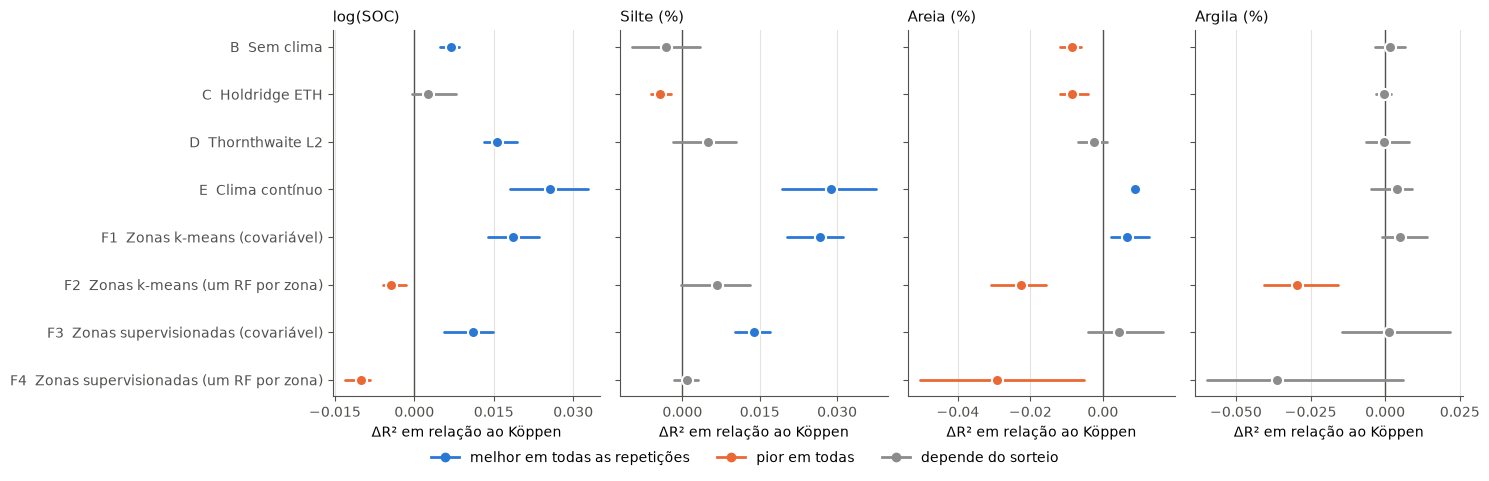

,ΔR² log(SOC),ΔR² Silte (%),ΔR² Areia (%),ΔR² Argila (%),ΔRMSE % log(SOC),ΔRMSE % Silte (%),ΔRMSE % Areia (%),ΔRMSE % Argila (%)
cenario,,,,,,,,
B Sem clima,0.007,-0.003,-0.009,0.001,-0.4,0.2,0.7,-0.1
C Holdridge ETH,0.003,-0.004,-0.009,-0.001,-0.2,0.3,0.7,0.0
D Thornthwaite L2,0.016,0.005,-0.003,-0.000,-1.0,-0.4,0.2,0.0
E Clima contínuo,0.026,0.029,0.009,0.004,-1.6,-2.2,-0.7,-0.3
F1 Zonas k-means (covariável),0.019,0.027,0.007,0.005,-1.1,-2.1,-0.5,-0.4
F2 Zonas k-means (um RF por zona),-0.004,0.007,-0.023,-0.029,0.3,-0.5,1.7,2.2
F3 Zonas supervisionadas (covariável),0.011,0.014,0.004,0.001,-0.7,-1.1,-0.3,-0.1
F4 Zonas supervisionadas (um RF por zona),-0.010,0.001,-0.029,-0.036,0.6,-0.1,2.2,2.7


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6), sharey=True)
for ax, (r, rot) in zip(axes, RESPOSTAS.items()):
    d = res[res.resposta == r].set_index('cenario').loc[ORDEM]
    ax.axvline(0, color=TINTA2, lw=1)
    for i, (cen, row) in enumerate(d.iterrows()):
        cls = 'melhor' if row.delta_r2_min > 0 else 'pior' if row.delta_r2_max < 0 else 'empate'
        ax.plot([row.delta_r2_min, row.delta_r2_max], [i, i], color=COR[cls], lw=2, solid_capstyle='round')
        ax.plot(row.delta_r2_vs_A, i, 'o', ms=8, color=COR[cls], markeredgecolor='white', markeredgewidth=1.5)
    ax.set_title(rot, loc='left', color=TINTA, fontsize=11)
    ax.grid(axis='x', color=GRADE, lw=0.8)
    ax.set_xlabel('ΔR² em relação ao Köppen')
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
axes[0].set_yticks(range(len(ORDEM)), [f'{c}  {DESC[c]}' for c in ORDEM])
axes[0].invert_yaxis()
import matplotlib.lines as ml
fig.legend(handles=[ml.Line2D([], [], color=COR[k], marker='o', lw=2, label=l) for k, l in
                    [('melhor', 'melhor em todas as repetições'), ('pior', 'pior em todas'), ('empate', 'depende do sorteio')]],
           loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.tight_layout()
plt.show()

g = res.pivot_table(index='cenario', columns='resposta', values='delta_r2_vs_A')[list(RESPOSTAS)].loc[ORDEM]
g.columns = [f'ΔR² {RESPOSTAS[c]}' for c in g.columns]
pr = res.pivot_table(index='cenario', columns='resposta', values='delta_rmse_pct_vs_A')[list(RESPOSTAS)].loc[ORDEM]
pr.columns = [f'ΔRMSE % {RESPOSTAS[c]}' for c in pr.columns]
display(pd.concat([g.round(3), pr.round(1)], axis=1).rename(index=lambda c: f'{c} {DESC[c]}'))

## 4. Leitura

- **E, clima contínuo, é o melhor cenário:** melhora SOC (+0,026; RMSE −1,6%), silte (+0,029; RMSE −2,2%)
  e areia (+0,009) em **todas** as repetições. Em argila o efeito é nulo, como na comparação de climas — a
  argila depende de material de origem e relevo, que as covariáveis-base já trazem.
- **F1, zonas homogêneas como covariável, fica logo atrás:** +0,019 em SOC e +0,027 em silte, também em
  todas as repetições (em areia +0,007, positivo nas 3). Com só 10 classes, captura cerca de 70% do ganho
  do clima contínuo em SOC e mais de 90% em silte.
- **Thornthwaite L2 (D) ajuda em SOC** (+0,016), mas não em textura. **Holdridge (C) quase não muda
  nada** — embora na comparação isolada fosse o melhor para SOC, dentro do modelo completo o que ele
  informa já está nas outras covariáveis (bioma, fitofisionomia, NDVI).
- **Tirar o Köppen (B) não piora o SOC** (fica até +0,007 melhor) e piora pouco a areia (−0,009): o
  Köppen contribui pouco no modelo atual. As dummies de muitas classes fragmentam a informação, e o random
  forest aproveita mal as colunas quase vazias.
- **As zonas supervisionadas (F3) ficam no meio:** melhores que o Köppen, piores que as zonas k-means.
  Ajustadas em ~10 mil locais concentrados em duas regiões, as fronteiras que elas aprendem generalizam pior
  para regiões novas do que as zonas desenhadas sobre o clima do país inteiro.

## 5. Estratificar (um modelo por zona) piora

F2 e F4 treinam um random forest separado para cada zona. Resultado: pior que o Köppen em SOC e bem pior
em areia e argila (−0,02 a −0,04 de R²); em silte, empata. Dois motivos:

1. **Cada modelo fica com uma fração dos dados** (as zonas vão de ~160 a ~3.900 locais), e o random forest
   perde muito com isso.
2. **Relações que valem em todo o Brasil** (por exemplo, argila × geologia) **precisam ser reaprendidas em
   cada zona**, e as zonas pequenas não têm dados para isso.

O random forest global com a zona como covariável (F1) já consegue usar interações zona × covariável
quando elas existem, sem pagar o preço de dividir os dados. **Para os modelos do MapBiomas, a zona deve
entrar como covariável, não como estratificação.**

## 6. As zonas climáticas homogêneas

Dez zonas obtidas por k-means sobre 9 variáveis climáticas padronizadas (temperatura média e do mês mais
frio, chuva anual e do mês mais seco, sazonalidade da chuva, ETP, DEF, EXC e Im), ajustadas nos pixels do
Brasil e numeradas da mais quente (1) para a mais fria (10).

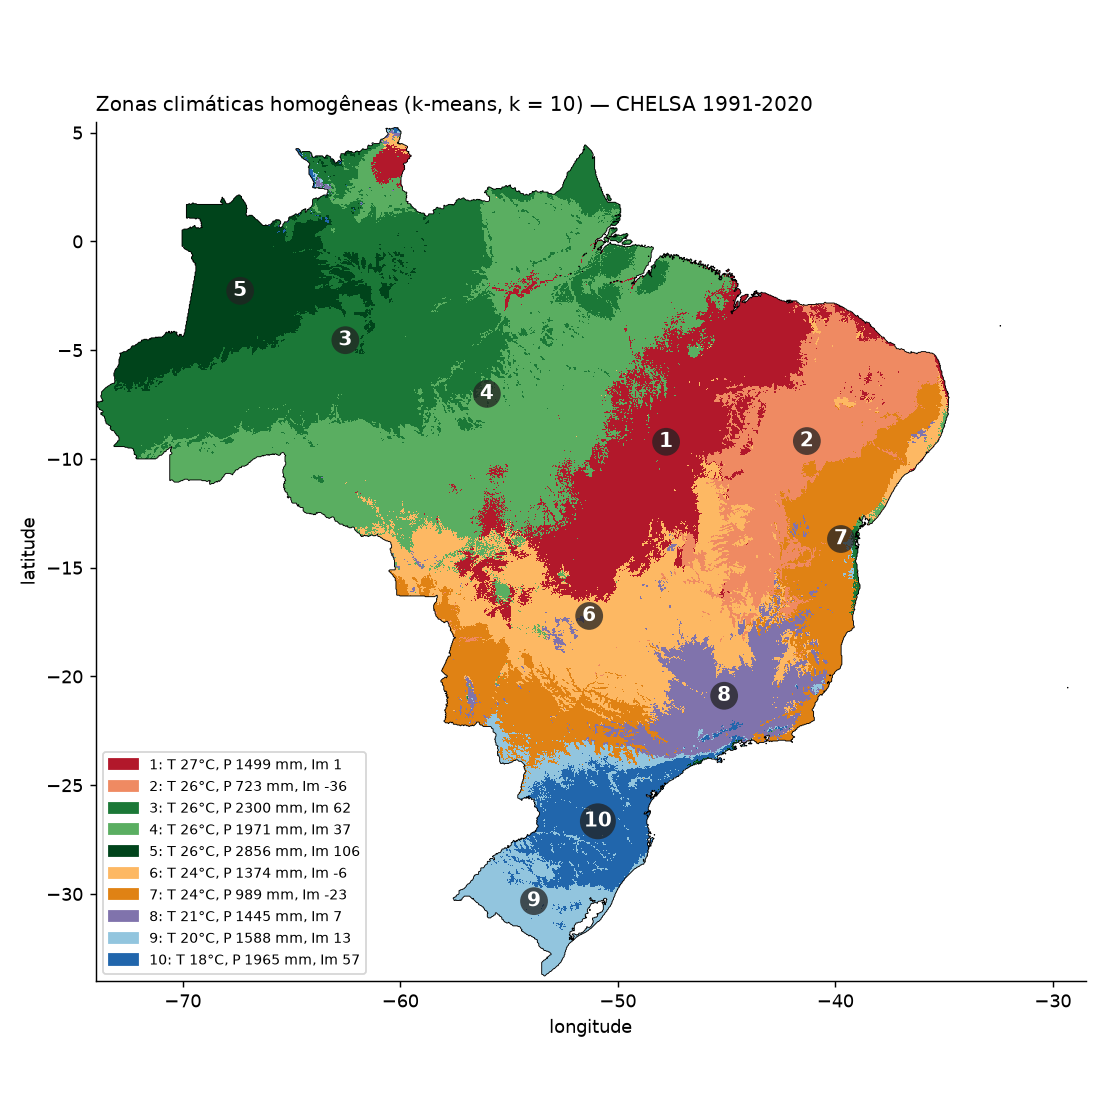

,t_media,t_mes_frio,p_anual,p_mes_seco,p_sazonalidade,etp_anual,def_anual,exc_anual,im
zona,,,,,,,,,
1,26.8,25.5,1499.3,2.1,0.8,1782.0,670.2,363.4,1.2
2,26.5,24.6,722.9,1.2,0.9,1911.6,1145.8,0.4,-36.4
3,26.0,25.2,2299.6,53.7,0.5,1463.8,108.5,949.9,62.1
4,25.8,24.8,1971.1,13.7,0.7,1552.6,349.4,758.5,37.4
5,25.6,24.9,2856.0,136.8,0.3,1399.6,0.9,1440.4,105.7
6,24.2,21.9,1373.5,5.1,0.8,1713.2,543.4,163.6,-5.7
7,24.2,21.0,988.7,22.9,0.5,1676.7,549.3,0.3,-22.6
8,21.2,18.1,1445.0,13.6,0.8,1496.2,300.9,215.5,6.9
9,19.9,14.6,1587.6,82.4,0.2,1452.0,51.2,171.9,12.8


In [4]:
display(Image('resultados/figuras/zonas_k10.png', width=720))
display(cent.round(1).rename(columns=lambda c: c.replace('clim_', '')))

**Leitura das zonas:**

- **3, 4 e 5 — Amazônia úmida:** gradiente de chuva de ~2.000 a ~2.900 mm, sem deficiência (DEF ≤ 350 mm)
  e com grande excedente. A zona 5 é o noroeste superúmido.
- **1 — tropical com seca sazonal** (Maranhão, Tocantins, Mato Grosso): ~1.500 mm, mas com 670 mm de
  deficiência — o cerrado do Centro-Norte.
- **2 — semiárido nordestino:** ~720 mm, Im −36, deficiência acima de 1.100 mm e nenhum excedente.
- **7 — seco-subúmido** (interior da Bahia e de Minas, Pantanal e oeste de MS): ~990 mm, Im −23, sem
  excedente.
- **6 — cerrado do Centro-Oeste e Sudeste:** ~1.370 mm, deficiência moderada.
- **8 — Sudeste de altitude:** mais frio (T média 21 °C), equilíbrio entre chuva e ETP.
- **9 e 10 — Sul:** mês mais frio de ~14 °C. A 10 é o planalto úmido (EXC ~660 mm); a 9, a Campanha e o
  oeste gaúcho, com chuva bem distribuída mas menos excedente.

As zonas separam bem regimes que o Köppen junta (por exemplo, o Köppen chama de Aw tanto o cerrado do
Centro-Norte quanto boa parte da transição amazônica) e são definidas por limiares de variáveis com sentido
físico direto para o solo (DEF, EXC, Im).

## 7. Recomendação para os modelos do MapBiomas

1. **Substituir as dummies do Köppen pelas variáveis climáticas contínuas** (cenário E). É o maior ganho,
   consistente em SOC, silte e areia. As 12 variáveis saem dos assets CHELSA 1991-2020 que já estão no GEE
   (`chelsa_brasil_{tas,pr,pet}_normal_1991_2020` e as bandas DEF/EXC/Im do Thornthwaite).
2. **Se for preciso manter uma covariável categórica** (interpretação, relatórios, mapas por região), usar
   **as zonas climáticas homogêneas (k = 10) como dummies** (cenário F1): ganho quase igual, 10 classes,
   mapa pronto (`zonas_climaticas_k10.tif`, que pode virar asset). Também dá para usar as duas coisas.
3. **Não estratificar** os modelos por zona climática.

**Limitações:**

- **Ganhos pequenos em valor absoluto:** o clima é uma entre ~100 covariáveis, e o bioma, a fitofisionomia
  e o NDVI já carregam parte do sinal climático. Ainda assim, +0,026 de R² em SOC é ~15% de ganho relativo
  e aparece em todas as repetições.
- **Não é o modelo exato do MapBiomas:** usamos random forest em todos os alvos (eles usam GBM por
  profundidade na textura, sobre razões log), uma linha por local (eles usam todas as réplicas) e
  hiperparâmetros fixos. A comparação entre cenários é justa porque só o clima muda, mas os valores
  absolutos de R² não são os deles. **O próximo passo é repetir o teste dentro do pipeline deles**, trocando
  só as colunas de clima.
- **Três repetições:** as diferenças destacadas aparecem em todas elas, mas intervalos mais precisos pedem
  mais repetições.
- **Amostra concentrada** (Rondônia e RS): a validação em blocos atenua, mas o ganho medido reflete mais
  essas regiões.

## 8. Como reproduzir

```bash
python codigo/preparar_dados.py        # classes climáticas nos pontos (GEE)
python codigo/experimento_dados.py     # matrizes completas + clima contínuo nos pontos (GEE) -> .local/dados/
python -c "import zonas_clima as z; z.main(ks=(10, 15))"   # (dentro de codigo/) zonas k-means + mapas
python codigo/experimento_modelos.py   # cenários A-F4 -> resultados/tabelas/experimento_*.csv (~75 min)
```

As zonas usam os rasters locais da pasta `climas/dados_chelsa/` (normais CHELSA e Thornthwaite); este
notebook lê só `resultados/`.